# **ACQUISITION TEST**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import sys

!pip install facenet-pytorch

cfg_path = "/content/drive/MyDrive/11/src"

if cfg_path not in sys.path:
    sys.path.append(cfg_path)

import cv2
import numpy as np
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from acquisition import BiometricAcquisition

## **Acquisizione Immagini da Webcam**

Poiché Google Colab viene eseguito su un server remoto, non può accedere direttamente alla periferica video locale. Questa sezione implementa un **bridge JavaScript-Python**:

1.  **Interfaccia Web:** Inietta codice JavaScript nel browser per attivare la webcam e mostrare un pulsante "Cattura Foto".
2.  **Trasmissione Dati:** L'immagine catturata viene convertita in una stringa **Base64** e inviata dal browser al kernel Python.
3.  **Decodifica:** Python riceve la stringa, la decodifica e la converte in un array NumPy compatibile con OpenCV.

In [ ]:
def _js_to_image(js_reply):
    if not js_reply or 'base64,' not in js_reply: return None
    try:
        image_bytes = b64decode(js_reply.split(',')[1])
        jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
        return cv2.imdecode(jpg_as_np, flags=1)
    except Exception: return None

def capture_image_colab(quality=0.8):
    """
    Questa è la funzione che passeremo alla classe.
    Non prende argomenti complessi, restituisce solo l'immagine o None.
    """
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Cattura Foto';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    try: return _js_to_image(eval_js('takePhoto({})'.format(quality)))
    except Exception: return None

## **Acquisizione Biometrica con Controllo Posa**

Questa fase esegue la cattura del volto applicando standard di qualità rigidi, simili a quelli usati nei sistemi di identificazione documenti (ICAO). Non basta che ci sia un volto; deve essere **frontale** e **nitido**.

Il sistema analizza in tempo reale:
1.  **Qualità Immagine:** Misura sfocatura (Laplacian Variance), contrasto e luminosità media.
2.  **Posa 3D (Yaw & Pitch):** Stima la rotazione della testa analizzando la geometria dei 5 landmarks facciali (occhi, naso, angoli bocca):
    * **Yaw (Rotazione Orizzontale):** Calcolato basandosi sulla simmetria delle distanze naso-bocca.
    * **Pitch (Inclinazione Verticale):** Calcolato valutando il rapporto tra la distanza occhi-naso e naso-bocca.



Se l'immagine supera i controlli, viene salvata come campione di riferimento (Enrollment). Altrimenti, il sistema ritenta o seleziona il "miglior candidato" disponibile.

[LIB] Detector inizializzato su cpu. Controllo Yaw + Pitch attivo.
Inizio procedura (Yaw Th: 0.2, Pitch Range: (0.4, 1.6))...

--- Tentativo 1/3 ---


<IPython.core.display.Javascript object>

Volto GIRATO(score 0.68): B=97, C=42
  -> RIFIUTATO: Testa girata orizzontalmente (0.68)

--- Tentativo 2/3 ---


<IPython.core.display.Javascript object>

Volto FRONTALE: B=549, C=63
Qualità e Posa 3D accettate!
Visualizzazione risultato finale:


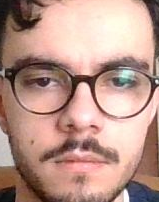

In [ ]:
acquisition = BiometricAcquisition(
    max_attempts=3,
    blur_threshold=300.0,
    min_face_size=100,
    symmetry_threshold=0.20,
    pitch_range=(0.40, 1.60)
)

face, timestamp = acquisition.acquire_best_sample(capture_function=capture_image_colab)

if face is not None:
    print("Visualizzazione risultato finale:")
    cv2_imshow(face)
else:
    print("Fallito.")